# Notebook 2 — CNN Segmentation of Neurons and Synapses with PyTorch

**BINFX410 · Chapter 10 · Connectomics**

---

## Learning Objectives

1. Implement a U-Net style encoder–decoder for binary segmentation in PyTorch
2. Build a custom `Dataset` and `DataLoader` for microscopy image patches
3. Train and validate the model using binary cross-entropy + Dice loss
4. Evaluate segmentation quality with IoU and F1 score
5. Run inference on a full-resolution image and extract detected soma / synapse centroids

---

## Background

**Image segmentation** assigns a class label to every pixel. Here we solve two parallel binary segmentation tasks:

| Task | Input | Output |
|------|-------|--------|
| Soma detection | grayscale image | pixel mask: 1 = inside soma |
| Synapse detection | grayscale image | pixel mask: 1 = synapse terminal |

We use a **U-Net** architecture — the standard workhorse for biomedical image segmentation — which combines a contracting encoder path (captures context) with an expanding decoder path (enables precise localization) connected by skip connections.

### Dice Loss
Because soma and synapse pixels are rare (class imbalance), binary cross-entropy alone can be dominated by the background. **Dice loss** directly optimizes the overlap between prediction and ground truth:

$$\mathcal{L}_{\text{Dice}} = 1 - \frac{2 |P \cap G|}{|P| + |G|}$$

We use a combined loss: $\mathcal{L} = 0.5 \cdot \mathcal{L}_{\text{BCE}} + 0.5 \cdot \mathcal{L}_{\text{Dice}}$

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from scipy import ndimage

DATA_DIR  = Path('../data')
MODEL_DIR = DATA_DIR

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Load dataset produced by Notebook 1
with open(DATA_DIR / 'connectome_dataset.pkl', 'rb') as f:
    dataset = pickle.load(f)

print(f'Train samples: {len(dataset["train"]["images"])}')
print(f'Val   samples: {len(dataset["val"]["images"])}')

Using device: cpu
Train samples: 40
Val   samples: 10


## 1. Dataset and DataLoader

In [2]:
class NeuronDataset(Dataset):
    """PyTorch Dataset for (image, soma_mask, synapse_mask) triples."""

    def __init__(self, images, soma_masks, synapse_masks, augment=False):
        self.images        = images        # (N, H, W) float32
        self.soma_masks    = soma_masks    # (N, H, W) uint8
        self.synapse_masks = synapse_masks # (N, H, W) uint8
        self.augment       = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img  = self.images[idx].copy()         # (H, W)
        soma = self.soma_masks[idx].astype(np.float32)
        syn  = self.synapse_masks[idx].astype(np.float32)

        if self.augment:
            # Random horizontal flip
            if np.random.rand() > 0.5:
                img  = np.fliplr(img).copy()
                soma = np.fliplr(soma).copy()
                syn  = np.fliplr(syn).copy()
            # Random vertical flip
            if np.random.rand() > 0.5:
                img  = np.flipud(img).copy()
                soma = np.flipud(soma).copy()
                syn  = np.flipud(syn).copy()
            # Random 90-degree rotation
            k = np.random.randint(0, 4)
            img  = np.rot90(img,  k).copy()
            soma = np.rot90(soma, k).copy()
            syn  = np.rot90(syn,  k).copy()
            # Small brightness jitter
            img = np.clip(img + np.random.uniform(-0.05, 0.05), 0, 1)

        # Add channel dimension: (1, H, W)
        img  = torch.from_numpy(img[None])
        soma = torch.from_numpy(soma[None])
        syn  = torch.from_numpy(syn[None])

        # Stack masks: (2, H, W)
        masks = torch.cat([soma, syn], dim=0)
        return img, masks


train_ds = NeuronDataset(
    dataset['train']['images'],
    dataset['train']['soma_masks'],
    dataset['train']['synapse_masks'],
    augment=True
)
val_ds = NeuronDataset(
    dataset['val']['images'],
    dataset['val']['soma_masks'],
    dataset['val']['synapse_masks'],
    augment=False
)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0)

# Verify shapes
imgs, masks = next(iter(train_loader))
print(f'Batch image shape : {imgs.shape}')   # (B, 1, H, W)
print(f'Batch mask shape  : {masks.shape}')  # (B, 2, H, W)

Batch image shape : torch.Size([8, 1, 256, 256])
Batch mask shape  : torch.Size([8, 2, 256, 256])


## 2. U-Net Architecture

In [3]:
class ConvBlock(nn.Module):
    """Two 3×3 conv layers with BatchNorm and ReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    Lightweight U-Net for dual-channel segmentation.
    Input  : (B, 1, H, W)  — single-channel greyscale
    Output : (B, 2, H, W)  — [soma logits, synapse logits]
    """
    def __init__(self, n_out=2, base_ch=32):
        super().__init__()
        ch = base_ch

        # Encoder
        self.enc1 = ConvBlock(1,      ch)      # 256 → 256
        self.enc2 = ConvBlock(ch,     ch * 2)  # 128 → 128
        self.enc3 = ConvBlock(ch * 2, ch * 4)  # 64  → 64

        # Bottleneck
        self.bottleneck = ConvBlock(ch * 4, ch * 8)  # 32 → 32

        # Decoder
        self.up3   = nn.ConvTranspose2d(ch * 8, ch * 4, kernel_size=2, stride=2)
        self.dec3  = ConvBlock(ch * 8, ch * 4)

        self.up2   = nn.ConvTranspose2d(ch * 4, ch * 2, kernel_size=2, stride=2)
        self.dec2  = ConvBlock(ch * 4, ch * 2)

        self.up1   = nn.ConvTranspose2d(ch * 2, ch,     kernel_size=2, stride=2)
        self.dec1  = ConvBlock(ch * 2, ch)

        self.pool  = nn.MaxPool2d(2)
        self.head  = nn.Conv2d(ch, n_out, kernel_size=1)

    def forward(self, x):
        # Encode
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))

        # Decode with skip connections
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.head(d1)  # raw logits


model = UNet(n_out=2, base_ch=32).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net parameters: {n_params:,}')

# Quick shape test
with torch.no_grad():
    test_out = model(imgs.to(DEVICE))
print(f'Output shape: {test_out.shape}')  # (B, 2, H, W)

U-Net parameters: 1,926,466
Output shape: torch.Size([8, 2, 256, 256])


## 3. Loss Functions and Metrics

In [4]:
def dice_loss(pred_probs, targets, eps=1e-6):
    """Soft Dice loss. pred_probs and targets both (B, C, H, W) in [0,1]."""
    intersection = (pred_probs * targets).sum(dim=(-2, -1))
    union        = pred_probs.sum(dim=(-2, -1)) + targets.sum(dim=(-2, -1))
    dice         = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


def combined_loss(logits, targets):
    bce   = F.binary_cross_entropy_with_logits(logits, targets)
    probs = torch.sigmoid(logits)
    dice  = dice_loss(probs, targets)
    return 0.5 * bce + 0.5 * dice


def iou_score(pred_probs, targets, threshold=0.5):
    pred_bin = (pred_probs > threshold).float()
    inter    = (pred_bin * targets).sum(dim=(-2, -1))
    union    = pred_bin.sum(dim=(-2, -1)) + targets.sum(dim=(-2, -1)) - inter
    return (inter / (union + 1e-6)).mean().item()


print('Loss functions defined.')

Loss functions defined.


## 4. Training Loop

In [5]:
EPOCHS = 30
LR     = 3e-4

optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {'train_loss': [], 'val_loss': [], 'val_iou_soma': [], 'val_iou_syn': []}

best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    # --- Training ---
    model.train()
    train_loss_sum = 0.0
    for imgs_b, masks_b in train_loader:
        imgs_b  = imgs_b.to(DEVICE)
        masks_b = masks_b.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs_b)
        loss   = combined_loss(logits, masks_b)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item()

    scheduler.step()
    avg_train_loss = train_loss_sum / len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss_sum = 0.0
    iou_soma_sum = 0.0
    iou_syn_sum  = 0.0
    with torch.no_grad():
        for imgs_b, masks_b in val_loader:
            imgs_b  = imgs_b.to(DEVICE)
            masks_b = masks_b.to(DEVICE)
            logits  = model(imgs_b)
            val_loss_sum += combined_loss(logits, masks_b).item()
            probs    = torch.sigmoid(logits)
            iou_soma_sum += iou_score(probs[:, 0:1], masks_b[:, 0:1])
            iou_syn_sum  += iou_score(probs[:, 1:2], masks_b[:, 1:2])

    avg_val_loss = val_loss_sum  / len(val_loader)
    avg_iou_soma = iou_soma_sum  / len(val_loader)
    avg_iou_syn  = iou_syn_sum   / len(val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_iou_soma'].append(avg_iou_soma)
    history['val_iou_syn'].append(avg_iou_syn)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), MODEL_DIR / 'unet_best.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'train={avg_train_loss:.4f} val={avg_val_loss:.4f} | '
              f'IoU soma={avg_iou_soma:.3f} syn={avg_iou_syn:.3f}')

print(f'\nBest val loss: {best_val_loss:.4f}')

Epoch   1/30 | train=0.7912 val=0.8221 | IoU soma=0.079 syn=0.002
Epoch   5/30 | train=0.6885 val=0.7752 | IoU soma=0.159 syn=0.000
Epoch  10/30 | train=0.6459 val=0.6776 | IoU soma=0.436 syn=0.000
Epoch  15/30 | train=0.6246 val=0.6316 | IoU soma=0.648 syn=0.000
Epoch  20/30 | train=0.6128 val=0.6133 | IoU soma=0.673 syn=0.000
Epoch  25/30 | train=0.6080 val=0.6057 | IoU soma=0.714 syn=0.000
Epoch  30/30 | train=0.6074 val=0.6021 | IoU soma=0.693 syn=0.000

Best val loss: 0.6021


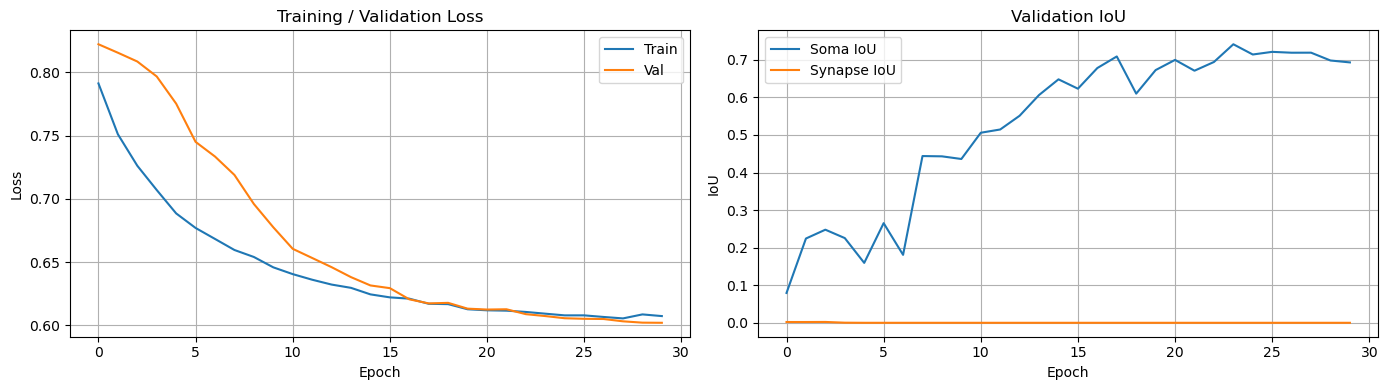

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training / Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['val_iou_soma'], label='Soma IoU')
axes[1].plot(history['val_iou_syn'],  label='Synapse IoU')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IoU')
axes[1].set_title('Validation IoU')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Inference on the Full-Resolution Scene

In [7]:
# Load best weights
model.load_state_dict(torch.load(MODEL_DIR / 'unet_best.pt', map_location=DEVICE))
model.eval()

infer = dataset['inference']
img_full = infer['image']  # (512, 512) float32

# The model was trained on 256×256 patches; tile the 512×512 image
def predict_full(model, img, tile=256, overlap=32, device=DEVICE):
    H, W = img.shape
    soma_logits_acc = np.zeros((H, W), dtype=np.float32)
    syn_logits_acc  = np.zeros((H, W), dtype=np.float32)
    count_acc       = np.zeros((H, W), dtype=np.float32)
    step = tile - overlap

    rows = list(range(0, H - tile + 1, step)) + [H - tile]
    cols = list(range(0, W - tile + 1, step)) + [W - tile]

    with torch.no_grad():
        for r in rows:
            for c in cols:
                patch = img[r:r+tile, c:c+tile]
                t = torch.from_numpy(patch[None, None]).to(device)  # (1,1,H,W)
                out = model(t).cpu().numpy()[0]  # (2, tile, tile)
                soma_logits_acc[r:r+tile, c:c+tile] += out[0]
                syn_logits_acc [r:r+tile, c:c+tile] += out[1]
                count_acc      [r:r+tile, c:c+tile] += 1.0

    soma_probs = 1 / (1 + np.exp(-soma_logits_acc / (count_acc + 1e-8)))
    syn_probs  = 1 / (1 + np.exp(-syn_logits_acc  / (count_acc + 1e-8)))
    return soma_probs, syn_probs


soma_probs, syn_probs = predict_full(model, img_full)
print(f'Soma prob range  : [{soma_probs.min():.3f}, {soma_probs.max():.3f}]')
print(f'Synapse prob range: [{syn_probs.min():.3f}, {syn_probs.max():.3f}]')

Soma prob range  : [0.182, 0.992]
Synapse prob range: [0.216, 0.545]


In [ ]:
SOMA_THRESH    = 0.5
SYNAPSE_THRESH = 0.4

soma_pred    = (soma_probs  > SOMA_THRESH).astype(np.uint8)
synapse_pred = (syn_probs   > SYNAPSE_THRESH).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].imshow(img_full, cmap='gray')
axes[0, 0].set_title('Input Image')

axes[0, 1].imshow(infer['soma_mask'], cmap='hot')
axes[0, 1].set_title('Soma GT')

axes[0, 2].imshow(soma_pred, cmap='hot')
axes[0, 2].set_title('Soma Predicted')

axes[1, 0].imshow(soma_probs, cmap='viridis')
axes[1, 0].set_title('Soma Probability Map')

axes[1, 1].imshow(infer['synapse_mask'], cmap='hot')
axes[1, 1].set_title('Synapse GT')

axes[1, 2].imshow(synapse_pred, cmap='hot')
axes[1, 2].set_title('Synapse Predicted')

for ax in axes.flat:
    ax.axis('off')

plt.suptitle('Segmentation Results — Full-Resolution Image', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Extract Centroids and Save for Connectome Construction

In [ ]:
def extract_centroids(binary_mask, min_size=50):
    """Label connected components and return (row, col) centroids."""
    labeled, n_labels = ndimage.label(binary_mask)
    centroids = []
    for label_id in range(1, n_labels + 1):
        region = labeled == label_id
        if region.sum() >= min_size:
            coords = np.argwhere(region)
            centroid = coords.mean(axis=0)
            centroids.append(tuple(centroid))
    return centroids


detected_soma     = extract_centroids(soma_pred,    min_size=80)
detected_synapses = extract_centroids(synapse_pred, min_size=20)

print(f'Detected soma     : {len(detected_soma)}')
print(f'Ground-truth soma : {len(infer["neurons"])}')
print(f'Detected synapses : {len(detected_synapses)}')
print(f'Ground-truth syns : {len(infer["synapses"])}')

# Show detections on the image
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(img_full, cmap='gray')
for r, c in detected_soma:
    circle = plt.Circle((c, r), radius=15, fill=False, color='lime', linewidth=2)
    ax.add_patch(circle)
for r, c in detected_synapses:
    ax.plot(c, r, 'r+', markersize=10, markeredgewidth=2)

import matplotlib.patches as mpatches
green = mpatches.Patch(facecolor='none', edgecolor='lime', label=f'Soma ({len(detected_soma)} detected)')
red   = mpatches.Patch(color='red', label=f'Synapse ({len(detected_synapses)} detected)')
ax.legend(handles=[green, red], fontsize=11, loc='upper right')
ax.set_title('CNN Detection Results', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Save segmentation results for Notebook 3
seg_results = {
    'detected_soma'     : detected_soma,
    'detected_synapses' : detected_synapses,
    'soma_probs'        : soma_probs,
    'syn_probs'         : syn_probs,
    'soma_pred'         : soma_pred,
    'synapse_pred'      : synapse_pred,
    'image'             : img_full,
    'gt_neurons'        : infer['neurons'],
    'gt_synapses'       : infer['synapses'],
}

with open(DATA_DIR / 'segmentation_results.pkl', 'wb') as f:
    pickle.dump(seg_results, f)

print('Segmentation results saved.')

---

## Student Exercises

**Exercise 2.1** — What is the purpose of the skip connections in U-Net? What information would be lost without them? Illustrate by modifying the `forward()` method to remove one skip connection and retraining.

**Exercise 2.2** — Compare training with pure BCE loss vs. the combined BCE + Dice loss. Plot IoU curves for both. Which converges faster and why?

**Exercise 2.3** — The `base_ch=32` hyperparameter controls model capacity. Train with `base_ch=16` and `base_ch=64`. Report the number of parameters and final validation IoU for each. Is the improvement from 32→64 worth the cost?

**Exercise 2.4** — Implement a simple **threshold sweep**: vary `SOMA_THRESH` from 0.2 to 0.8 in steps of 0.05 and plot precision vs. recall (PR curve) for soma detection. What threshold maximizes F1?

**Exercise 2.5 (Challenge)** — Add a third output channel to the U-Net to simultaneously predict **axon pixels** (you will need to add axon ground-truth masks to `neuron_sim.py`). Retrain and evaluate.